# Example of the AiTLAS toolbox for image generation using TerraMind

## Define the FAIREOSchema for dataset import

In [1]:
from marshmallow import fields

from aitlas.base.schemas import BaseDatasetSchema


class FAIREOSchema(BaseDatasetSchema):
    """
    Schema for FAIREO datasets.
    """

    csv_file = fields.String(
        load_default=None,
        metadata={"description": "CSV file on disk", "example": "./data/train.csv"},
    )
    data_dir = fields.String(
        load_default="/",
        metadata={"description": "Dataset path on disk", "example": "./data/CESBIO/"},
    )
    selection = fields.String(
        load_default="rgb",
        metadata={"description": "Read RGB channels or 13 channels", "example": "all/rgb"},
    )

/home/dragik/anaconda3/envs/aitlas-py312/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Define the Five Billion Pixels dataset

Five Billion Pixels is a large-scake land cover classification dataset. 
It covers areas of more than 50,000 square kilometers in China, and contains 
more than 5 billion labeled pixels. It possesses the advantage of rich 
categories, large coverage, wide distribution, and high-spatial resolution, 
which well reflects the distributions of real-world ground objects and can 
benefit to different land cover related studies. Link: https://drive.google.com/drive/folders/1924VnO08Gqo3Nv7Y4KirgJ9kqqCup7f0

In [2]:
import csv
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from aitlas.datasets.semantic_segmentation import SemanticSegmentationDataset
from aitlas.utils import image_loader


"""
Five Billion Pixels is a large-scake land cover classification dataset. 
It covers areas of more than 50,000 square kilometers in China, and contains 
more than 5 billion labeled pixels. It possesses the advantage of rich 
categories, large coverage, wide distribution, and high-spatial resolution, 
which well reflects the distributions of real-world ground objects and can 
benefit to different land cover related studies.
"""


class FiveBillionPixelsDataset(SemanticSegmentationDataset):
    url = "https://drive.google.com/drive/folders/1924VnO08Gqo3Nv7Y4KirgJ9kqqCup7f0"

    labels = [
        "unlabeled",
        "industrial area",
        "paddy field",
        "irrigated field",
        "dry cropland",
        "garden land",
        "arbor forest",
        "shrub forest",
        "park",
        "natural meadow",
        "artificial meadow",
        "river",
        "urban residential",
        "lake",
        "pond",
        "fish pond",
        "snow",
        "bareland",
        "rural residential",
        "stadium",
        "square",
        "road",
        "overpass",
        "railway station",
        "airport",
    ]
    color_mapping = [
        [0, 0, 0],
        [200, 0, 0],
        [0, 200, 0],
        [150, 250, 0],
        [150, 200, 150],
        [200, 0, 200],
        [150, 0, 250],
        [150, 150, 250],
        [200, 150, 200],
        [250, 200, 0],
        [200, 200, 0],
        [0, 0, 200],
        [250, 0, 150],
        [0, 150, 200],
        [0, 200, 250],
        [150, 200, 250],
        [250, 250, 250],
        [200, 200, 200],
        [200, 150, 150],
        [250, 200, 150],
        [150, 150, 0],
        [250, 150, 150],
        [250, 150, 0],
        [250, 200, 250],
        [200, 150, 0],
    ]
    name = "Five Billion Pixels"
    schema = FAIREOSchema

    def __init__(self, config):
        # now call the constructor to validate the schema and split the data
        super().__init__(config)
        self.data_dir = self.config.data_dir
        self.selection = self.config.selection
        self.csv_file = self.config.csv_file

    def __getitem__(self, index):
        mask = image_loader(self.masks[index])
        masks = [(mask == v) for v, label in enumerate(self.labels)]
        mask = np.stack(masks, axis=-1).astype("float32")

        if self.selection == "rgb":
            image = image_loader(self.images[index])
            image = image[:, :, 1:4]
            if self.transform:
                image = self.transform(image)
            if self.target_transform:
                mask = self.target_transform(mask)
            return image, mask

        if self.selection == "all":
            image = image_loader(self.images[index])

            if self.transform:
                image = self.transform(image)
            if self.target_transform:
                mask = self.target_transform(mask)

            return image, mask

    def load_dataset(self, data_dir, csv_file):
        if not self.labels:
            raise ValueError("You need to provide the list of labels for the dataset")

        ids = os.listdir(os.path.join(data_dir, "images"))

        split_list = []
        ids_final = []
        if csv_file:
            with open(csv_file, mode="r") as file:
                csvFile = csv.reader(file)
                for lines in csvFile:
                    split_list.append(lines[0])
            for i in ids:
                i_csv = "images/" + i
                if i_csv in split_list:
                    ids_final.append(i)
            ids = ids_final

        self.images = [os.path.join(data_dir, "images", image_id) for image_id in ids]
        self.masks = [
            os.path.join(data_dir, "labels", image_id[: image_id.rfind(".tif")] + "_24label.png")
            for image_id in ids
        ]

    def data_distribution_table(self):
        label_dist = {key: 0 for key in self.labels}
        for i in np.arange(len(self.images)):  # because images have different sizes
            mask = self[i][1]
            for index, label in enumerate(self.labels):
                label_dist[self.labels[index]] += mask[:, :, index].sum()
        label_count = pd.DataFrame.from_dict(label_dist, orient="index")
        label_count.columns = ["Number of pixels"]
        label_count = label_count.astype(float)
        return label_count

    def data_distribution_barchart(self, show_title=True):
        label_count = self.data_distribution_table()
        fig, ax = plt.subplots(figsize=(12, 12))
        sns.barplot(data=label_count, x=label_count.index, y="Number of pixels", ax=ax)
        fig.autofmt_xdate()
        if show_title:
            ax.set_title("Labels distribution for {}".format(self.get_name()), pad=20, fontsize=18)
        return fig

/home/dragik/anaconda3/envs/aitlas-py312/lib/python3.12/site-packages/eolearn/__init__.py:13: UserWarning: You are currently using an outdated installation of `eo-learn` for submodules ['core', 'geometry']. You can find instructions on how to install `eo-learn` correctly at https://github.com/sentinel-hub/eo-learn/issues/733.
  warnings.warn(


# Visualize images and masks

Total number of patches: 146


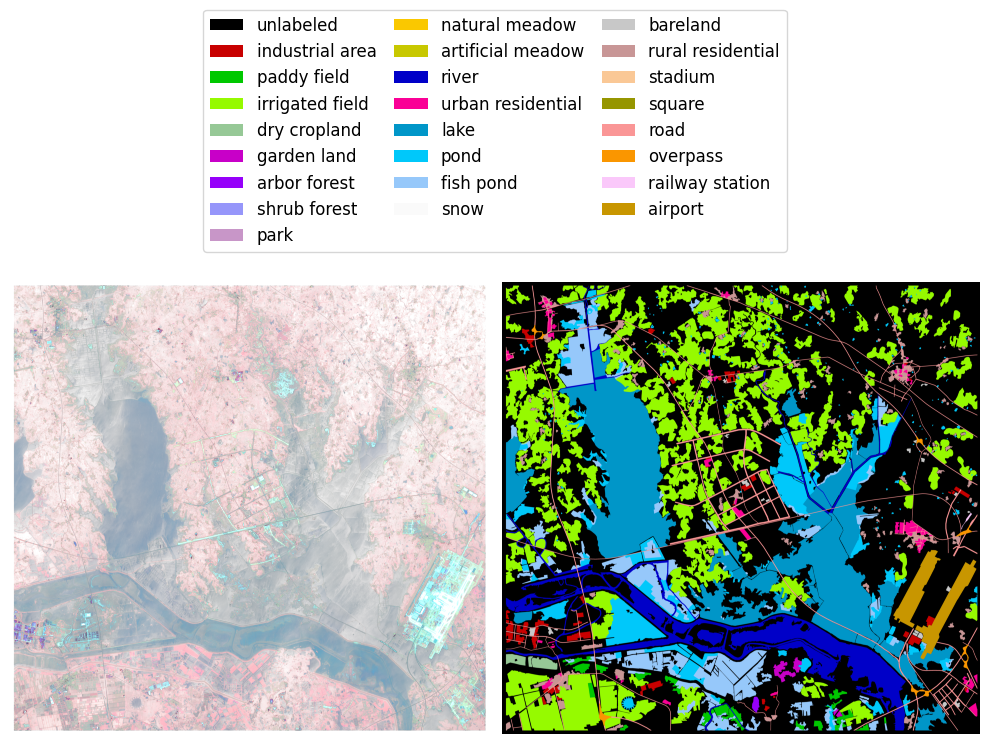

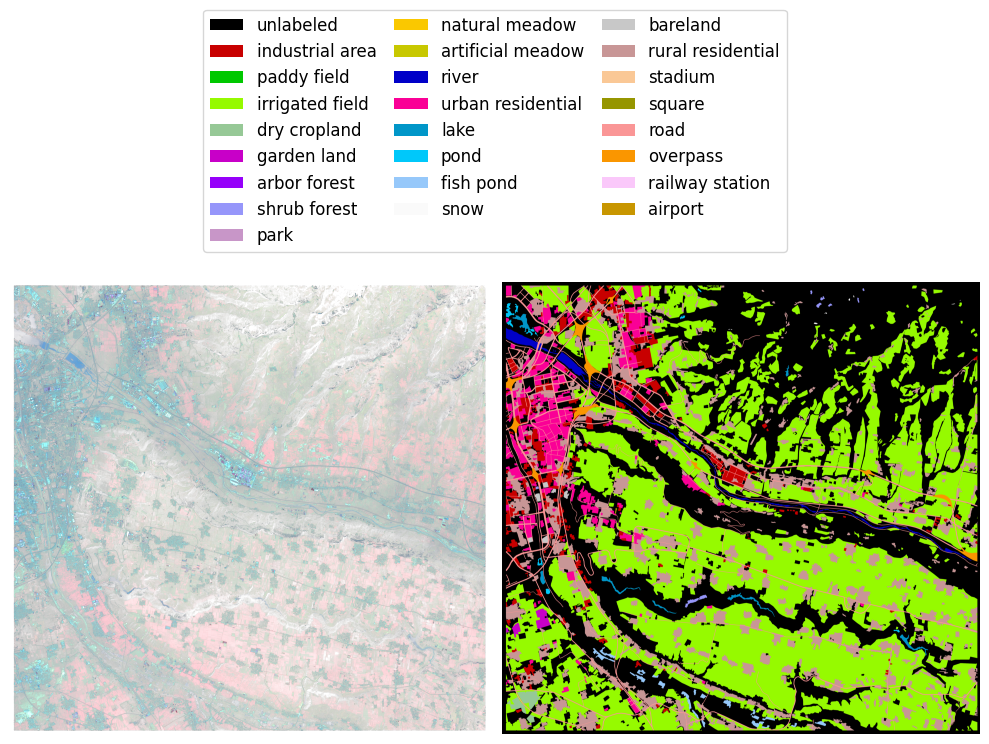

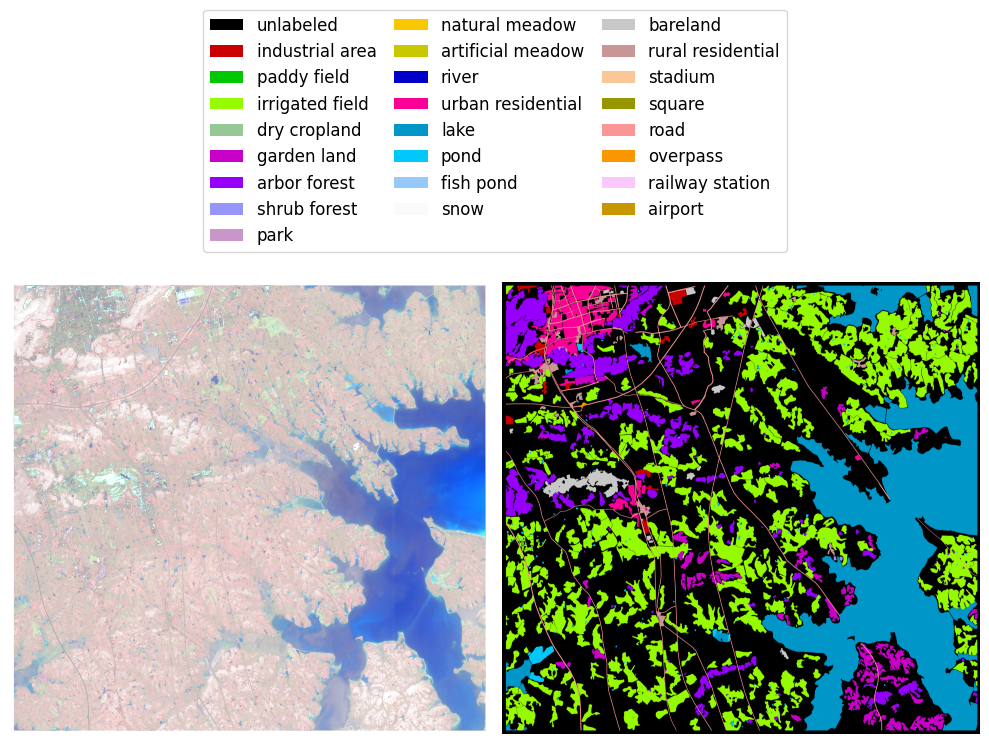

In [3]:
dataset_config = {"data_dir": "/home/dragik/data/FAIR_EO/five_billion_pixels", "selection": "all"}
dataset = FiveBillionPixelsDataset(dataset_config)

print(f"Total number of patches: {len(dataset)}")
dataset.show_image(1)
dataset.show_image(50)
dataset.show_image(100);

## Prepare the model

In [ ]:
import torch

from aitlas.models import TerraMind


model_config = {
    "local_model_path": "tests/checkpoints/TerraMind_v1_base.pt",
    "backbone_name": "terramind_v1_base_generate",
    "pretrained": True,
    "modalities": ["RGB"],
    "output_modalities": [
        "DEM",
        "S1RTC",
        "S2L2A",
    ],  # output_modalities is required for TerraMind any-to-any generation models
}

# Initialize the TerraMind model
model = TerraMind(model_config)

# Move model to the desired device
device = "cuda:1" if torch.cuda.is_available() else "cpu"
model.to(device)

print(f"Model loaded on device: {device}")

Loading weights from the provided local path: tests/checkpoints/TerraMind_v1_base.pt
Successfully loaded checkpoint: TerraMind_v1_base.pt
Model loaded on device: cuda:1


## Examples

### Load and process a single image

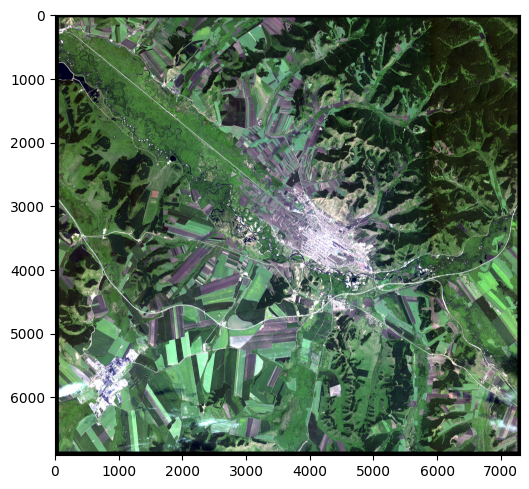

In [17]:
import torch
from torchvision.transforms import v2


# Path to the CSV file
csv_file = "/home/dragik/data/FAIR_EO/five_billion_pixels/five_billion_pixels_test.csv"
# Read the CSV file and extract the list of image filenames
test_list = []
with open(csv_file, mode="r") as file:
    csvFile = csv.reader(file)
    for lines in csvFile:
        test_list.append(lines[0])

# Load a single test image
image = image_loader("/home/dragik/data/FAIR_EO/five_billion_pixels/" + test_list[1])
rgb_image = torch.tensor(image, dtype=torch.float, device=device).permute(2, 0, 1)

# Preprocess the image
# Center crop the images and masks
transforms = v2.Compose([v2.Resize(448), v2.CenterCrop(224)])
rgb_image = transforms(rgb_image)
# Add a batch dimension and take just 3 channels
rgb_image = rgb_image[1:4, :, :].unsqueeze(0)

# Plot the original size RGB image
fig = plt.figure(figsize=(6, 6))
plt.imshow(image[:, :, 1:4])
plt.show()

### Infer the model

In [ ]:
# Prepare input data dictionary for the model
input_data = {"RGB": rgb_image}

# Generate the S2 images
generated_images = model.generate_images(x=input_data, standardize=True, verbose=True, timesteps=50)

100%|██████████| 50/50 [00:00<00:00, 53.48it/s]


### Plot the images

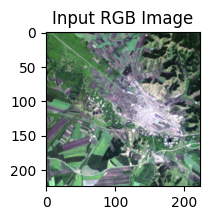

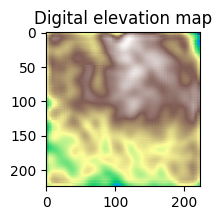

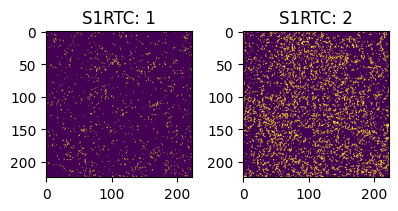

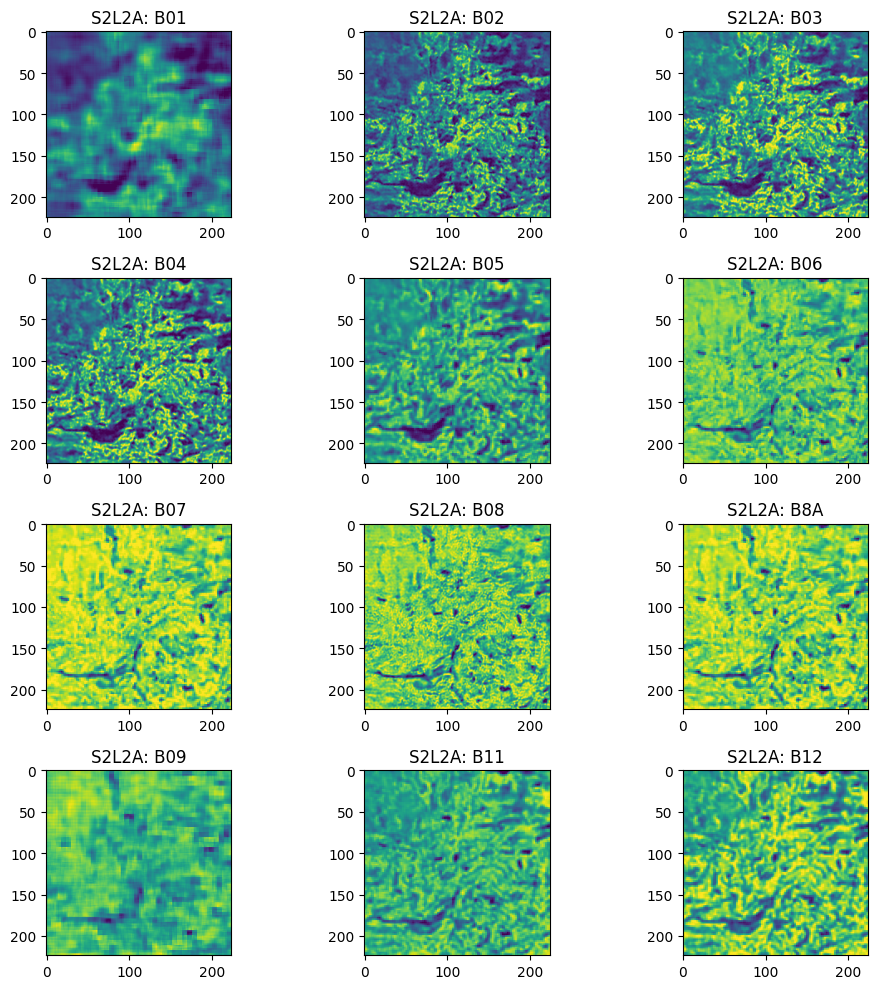

In [21]:
import matplotlib.pyplot as plt


# Get the input image
image_data_rgb = rgb_image.squeeze().permute(1, 2, 0).detach().cpu().numpy()
# Use uint8 for displaying
image_data_rgb = image_data_rgb.astype(np.uint8)

# Get the generated images as numpy arrays
image_data_dem = generated_images["DEM"][0].permute(1, 2, 0).detach().cpu().numpy()
image_data_s1rtc = generated_images["S1RTC"][0].permute(1, 2, 0).detach().cpu().numpy()
image_data_s2l2a = generated_images["S2L2A"][0].permute(1, 2, 0).detach().cpu().numpy()

# S1 bands
s1_bands = ["VV", "VH"]

# S2 bands
s2_bands = {
    "B01": 0.443,
    "B02": 0.490,
    "B03": 0.560,
    "B04": 0.665,
    "B05": 0.705,
    "B06": 0.740,
    "B07": 0.783,
    "B08": 0.842,
    "B8A": 0.865,
    "B09": 0.945,
    "B11": 1.610,
    "B12": 2.190,
}
s2_band_keys = list(s2_bands.keys())

# Plot the input RGB image
fig = plt.figure(figsize=(2, 2))
plt.imshow(image_data_rgb)
plt.title("Input RGB Image")
plt.show()

# Plot the DEM map
fig = plt.figure(figsize=(2, 2))
plt.imshow(image_data_dem[:, :, 0], cmap="terrain")
plt.title("Digital elevation map")
plt.show()

# Plot the generated S1RTC bands
fig = plt.figure(figsize=(10, 4))
for i in range(image_data_s1rtc.shape[2]):
    plt.subplot(2, 5, i + 1)
    plt.imshow(image_data_s1rtc[:, :, i].astype(np.uint8))
    plt.title(f"S1RTC: {i + 1}")
plt.tight_layout()
plt.show()

# Plot the generated S2L2A bands
fig = plt.figure(figsize=(10, 10))
for i in range(image_data_s2l2a.shape[2]):
    plt.subplot(4, 3, i + 1)
    plt.imshow(image_data_s2l2a[:, :, i])
    plt.title(f"S2L2A: {s2_band_keys[i]}")
plt.tight_layout()
plt.show()